## Run this in Google Colab

#### 1. Environment Setup
The notebook starts by installing the necessary signal processing and audio libraries:

- librosa: For loading audio and extracting features (MFCCs).
- webrtcvad: A commercial-grade VAD library from Google's WebRTC project.
- soundfile: For reading/writing WAV files.

#### 2. VAD Implementations
It defines two different approaches to speech detection:
- SimpleVAD (Energy-based): A baseline approach that calculates the Root Mean Square (RMS) energy of an audio chunk. If the energy exceeds a manually tuned threshold (e.g., 0.065), it is marked as speech. It uses a small history buffer to "smooth" the results and prevent flickering.
- WebRTCVADWrapper: A much more robust approach using the Google WebRTC VAD. It operates on 16-bit PCM audio at 16kHz and offers four levels of "aggressiveness" (0 to 3). This is the primary method used in the final project.

#### 3. Synthetic Audio Generation
To test the VAD without needing a microphone, the notebook includes a function to generate a "perfect" test file. It creates a .wav file that alternates between:
- Pure Silence: 2 seconds of zero-amplitude signal.
- Random Noise/Speech Simulation: 2 seconds of high-energy random values.

#### 4. Browser-Based Recording
The notebook includes a custom JavaScript bridge that allows you to record audio directly from your laptop's microphone while staying inside the Colab/Jupyter environment. It saves the recording as recorded.wav for immediate processing.

#### 5. Detection Pipeline & Visualization
The core logic iterates through an audio file in 30ms chunks (the standard for WebRTC VAD) and runs the detection. It then produces a detailed visualization using matplotlib:

- Top Plot: Shows the raw energy of the audio over time.
- Bottom Plot: A scatter plot showing exactly where "Speech" (colored) vs "Silence" (grey) was detected.

In [21]:
!pip install librosa numpy webrtcvad matplotlib soundfile

In [22]:
import numpy as np
import librosa
import os
from collections import deque

import matplotlib.pyplot as plt

In [63]:
class SimpleVAD:
    def __init__(self, sr=16000, energy_threshold=0.065):
        self.sr = sr
        self.threshold = energy_threshold
        self.history = deque(maxlen=3)

    def get_energy(self, audio):
        return np.sqrt(np.mean(audio**2))

    def detect(self, audio_chunk):
        energy = self.get_energy(audio_chunk)
        is_speech = energy > self.threshold

        self.history.append(is_speech)
        if len(self.history) >= 2:
            smoothed = sum(self.history) >= len(self.history) / 2
        else:
            smoothed = is_speech

        return smoothed, energy

In [53]:
class WebRTCVADWrapper:
    def __init__(self, sr=16000, aggressiveness=2):
        import webrtcvad
        # aggressiveness is an integer between 0 and 3.
        # 0 is the least aggressive about filtering out non-speech, 3 is the most aggressive.
        self.vad = webrtcvad.Vad(aggressiveness)
        self.sr = sr
        # WebRTC VAD only accepts frames of 10, 20, or 30ms.
        # At 16000Hz, 30ms is 480 samples.
        self.frame_duration_ms = 30
        self.frame_samples = int(sr * self.frame_duration_ms / 1000)

    def detect(self, audio_chunk):
        if len(audio_chunk) < self.frame_samples:
            return False, 0

        # We take a specific 30ms frame for the VAD check
        frame = audio_chunk[:self.frame_samples]
        # Convert float to 16-bit PCM
        frame_bytes = (frame * 32767).astype(np.int16).tobytes()

        try:
            is_speech = self.vad.is_speech(frame_bytes, self.sr)
            energy = np.sqrt(np.mean(frame**2))
            return is_speech, energy
        except Exception as e:
            return False, 0

In [69]:
def detect_speech_in_file(audio_file, use_webrtc=True, plot=True):
    print(f"\nProcessing: {audio_file}")

    audio, sr = librosa.load(audio_file, sr=16000)
    duration = len(audio) / sr
    print(f"Duration: {duration:.1f}s")

    # Initialize the preferred detector
    try:
        detector = WebRTCVADWrapper(sr=sr, aggressiveness=3)
        print("Using WebRTC VAD (High Aggressiveness)")
    except:
        detector = SimpleVAD(sr=sr, energy_threshold=0.065)
        print("Using Energy VAD (Tuned Threshold)")

    # Detection settings
    frame_size = 0.03  # 30ms frames for better precision
    frame_samples = int(sr * frame_size)

    results = []
    speech_flags = []

    # Iterate through the audio in small frames
    for start in range(0, len(audio) - frame_samples, frame_samples):
        chunk = audio[start:start + frame_samples]
        is_speech, energy = detector.detect(chunk)

        results.append({
            'time': start / sr,
            'is_speech': is_speech,
            'energy': energy
        })

    if plot:
        plot_results(results)

    return results

In [70]:
def plot_results(results):
    times = [r['time'] for r in results]
    energies = [r['energy'] for r in results]
    speech = [r['is_speech'] for r in results]

    plt.figure(figsize=(12, 5))

    plt.plot(times, energies)
    plt.title("Energy over Time")
    plt.xlabel("Time (s)")
    plt.ylabel("Energy")
    plt.grid()

    plt.show()

    plt.figure(figsize=(12, 2))
    colors = ['green' if s else 'red' for s in speech]
    plt.scatter(times, [1]*len(times), c=colors)
    plt.title("Speech Detection")
    plt.yticks([])
    plt.show()

In [71]:
import soundfile as sf

def generate_test_audio(output_file='test_audio.wav'):
    sr = 16000
    audio = np.array([])

    segments = [
        ('silence', 2),
        ('speech', 3),
        ('silence', 2),
        ('speech', 3)
    ]

    for seg_type, seg_duration in segments:
        if seg_type == 'silence':
            segment = np.random.normal(0, 0.001, int(sr * seg_duration))
        else:
            segment = np.random.normal(0, 0.05, int(sr * seg_duration))

        audio = np.concatenate([audio, segment])

    audio = audio / np.max(np.abs(audio))

    sf.write(output_file, audio, sr)
    return output_file


Processing: test_audio.wav
Duration: 10.0s
Using WebRTC VAD (High Aggressiveness)


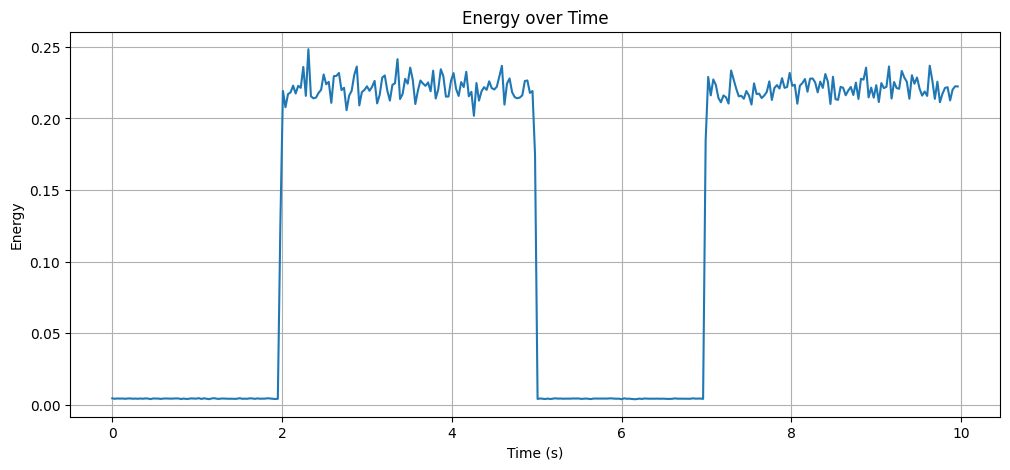

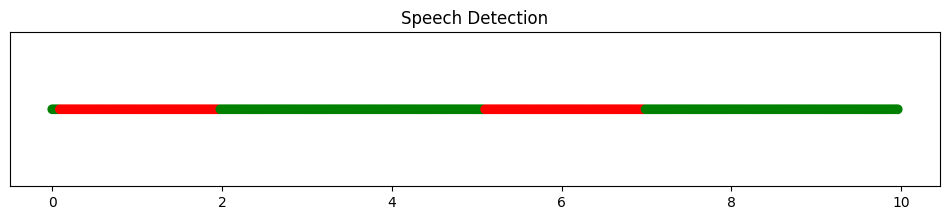

[{'time': 0.0, 'is_speech': True, 'energy': np.float32(0.0046794014)},
 {'time': 0.03, 'is_speech': True, 'energy': np.float32(0.0043408936)},
 {'time': 0.06, 'is_speech': True, 'energy': np.float32(0.004560532)},
 {'time': 0.09, 'is_speech': False, 'energy': np.float32(0.004466462)},
 {'time': 0.12, 'is_speech': False, 'energy': np.float32(0.004538203)},
 {'time': 0.15, 'is_speech': False, 'energy': np.float32(0.004326941)},
 {'time': 0.18, 'is_speech': False, 'energy': np.float32(0.0045358604)},
 {'time': 0.21, 'is_speech': False, 'energy': np.float32(0.0045918003)},
 {'time': 0.24, 'is_speech': False, 'energy': np.float32(0.004371041)},
 {'time': 0.27, 'is_speech': False, 'energy': np.float32(0.0044960734)},
 {'time': 0.3, 'is_speech': False, 'energy': np.float32(0.0043693595)},
 {'time': 0.33, 'is_speech': False, 'energy': np.float32(0.004531372)},
 {'time': 0.36, 'is_speech': False, 'energy': np.float32(0.004394979)},
 {'time': 0.39, 'is_speech': False, 'energy': np.float32(0.0045

In [72]:
audio_file = generate_test_audio()
detect_speech_in_file(audio_file)

In [73]:
from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode

def record_audio(seconds=5):
    js = Javascript("""
    async function record(sec) {
      const stream = await navigator.mediaDevices.getUserMedia({audio: true});
      const recorder = new MediaRecorder(stream);
      let chunks = [];

      recorder.ondataavailable = e => chunks.push(e.data);
      recorder.start();

      await new Promise(resolve => setTimeout(resolve, sec * 1000));

      recorder.stop();
      await new Promise(resolve => recorder.onstop = resolve);

      const blob = new Blob(chunks);
      return new Promise(resolve => {
        const reader = new FileReader();
        reader.onloadend = () => resolve(reader.result.split(',')[1]); // Extract base64 part
        reader.readAsDataURL(blob);
      });
    }
    """)
    display(js)
    audio = eval_js(f"record({seconds})")

    with open("recorded.wav", "wb") as f:
        f.write(b64decode(audio))

In [74]:
record_audio(10) # Voice Test

<IPython.core.display.Javascript object>


Processing: recorded.wav
Duration: 10.0s
Using WebRTC VAD (High Aggressiveness)


/tmp/ipykernel_333/3111560476.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_file, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


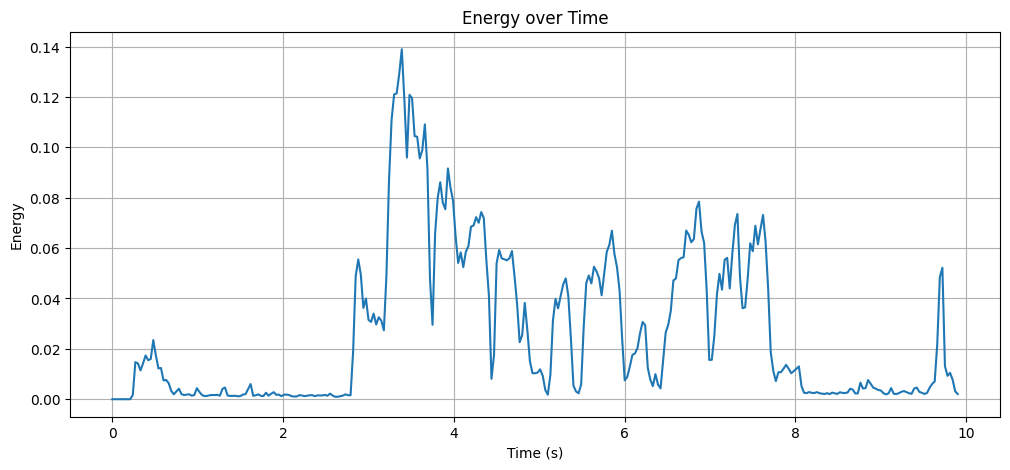

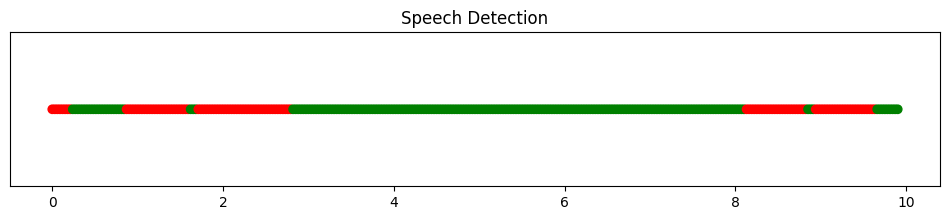

[{'time': 0.0, 'is_speech': False, 'energy': np.float32(0.0)},
 {'time': 0.03, 'is_speech': False, 'energy': np.float32(0.0)},
 {'time': 0.06, 'is_speech': False, 'energy': np.float32(0.0)},
 {'time': 0.09, 'is_speech': False, 'energy': np.float32(0.0)},
 {'time': 0.12, 'is_speech': False, 'energy': np.float32(0.0)},
 {'time': 0.15, 'is_speech': False, 'energy': np.float32(0.0)},
 {'time': 0.18, 'is_speech': False, 'energy': np.float32(0.0)},
 {'time': 0.21, 'is_speech': False, 'energy': np.float32(0.0)},
 {'time': 0.24, 'is_speech': True, 'energy': np.float32(0.0017001)},
 {'time': 0.27, 'is_speech': True, 'energy': np.float32(0.014695863)},
 {'time': 0.3, 'is_speech': True, 'energy': np.float32(0.014233409)},
 {'time': 0.33, 'is_speech': True, 'energy': np.float32(0.011445981)},
 {'time': 0.36, 'is_speech': True, 'energy': np.float32(0.014193025)},
 {'time': 0.39, 'is_speech': True, 'energy': np.float32(0.017372357)},
 {'time': 0.42, 'is_speech': True, 'energy': np.float32(0.01549723

In [75]:
detect_speech_in_file("recorded.wav")

<IPython.core.display.Javascript object>


Processing: recorded.wav
Duration: 6.4s
Using WebRTC VAD (High Aggressiveness)


/tmp/ipykernel_333/3111560476.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_file, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


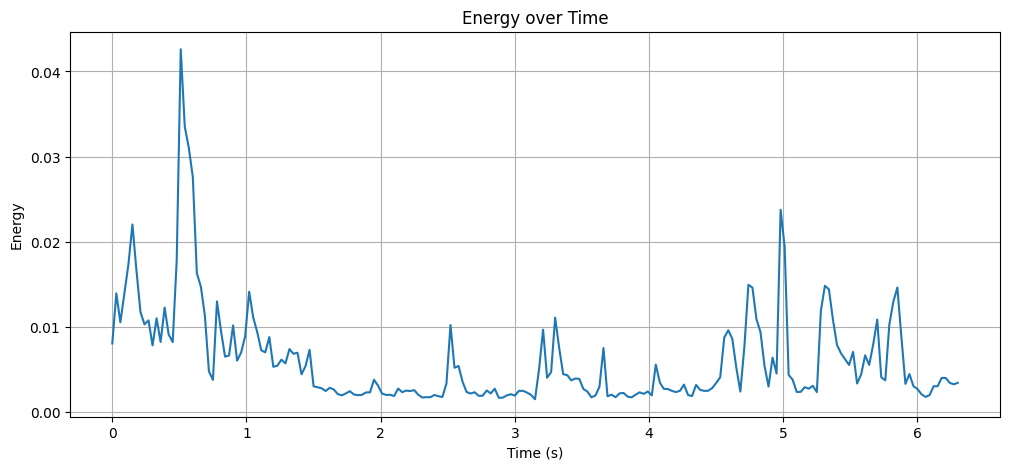

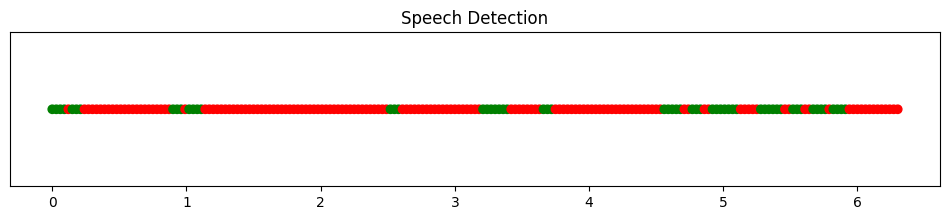

[{'time': 0.0, 'is_speech': True, 'energy': np.float32(0.008090602)},
 {'time': 0.03, 'is_speech': True, 'energy': np.float32(0.013974757)},
 {'time': 0.06, 'is_speech': True, 'energy': np.float32(0.010564248)},
 {'time': 0.09, 'is_speech': True, 'energy': np.float32(0.01392365)},
 {'time': 0.12, 'is_speech': False, 'energy': np.float32(0.017348204)},
 {'time': 0.15, 'is_speech': True, 'energy': np.float32(0.02204959)},
 {'time': 0.18, 'is_speech': True, 'energy': np.float32(0.016637512)},
 {'time': 0.21, 'is_speech': True, 'energy': np.float32(0.011759221)},
 {'time': 0.24, 'is_speech': False, 'energy': np.float32(0.010330848)},
 {'time': 0.27, 'is_speech': False, 'energy': np.float32(0.010793357)},
 {'time': 0.3, 'is_speech': False, 'energy': np.float32(0.00785706)},
 {'time': 0.33, 'is_speech': False, 'energy': np.float32(0.0110394815)},
 {'time': 0.36, 'is_speech': False, 'energy': np.float32(0.008263737)},
 {'time': 0.39, 'is_speech': False, 'energy': np.float32(0.012296355)},
 {'

In [76]:
record_audio(6)
detect_speech_in_file("recorded.wav")


Processing: office_normal.wav
Duration: 300.0s
Using WebRTC VAD (High Aggressiveness)


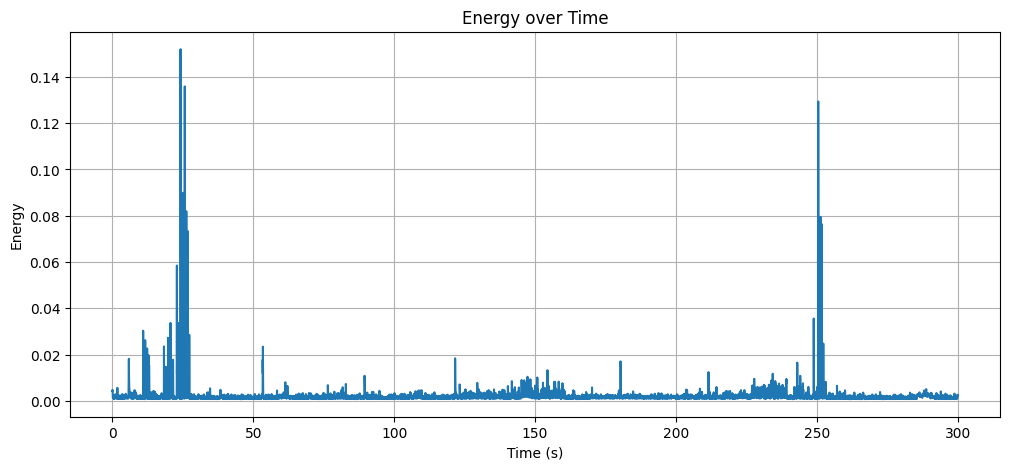

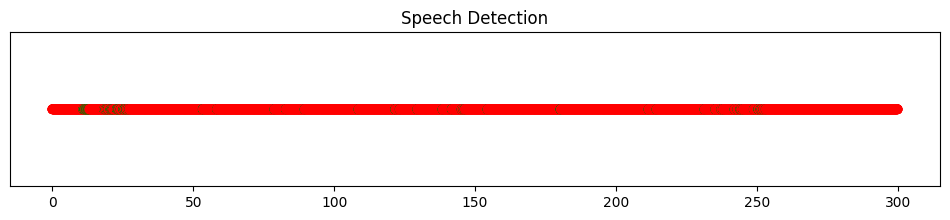


Analysis complete.
Total detected speech duration: 7.08 seconds


In [77]:
# Import and test the office_normal.wav file
audio_file = 'office_normal.wav'

if os.path.exists(audio_file):
    # Process the file using our tuned detection function
    results = detect_speech_in_file(audio_file)

    # Calculate total speech duration
    # Each frame in results is 30ms (0.03s)
    speech_frames = sum(1 for r in results if r['is_speech'])
    total_speech_duration = speech_frames * 0.03
    print(f"\nAnalysis complete.")
    print(f"Total detected speech duration: {total_speech_duration:.2f} seconds")
else:
    print(f"Error: {audio_file} not found in the current directory.")


Processing: ch08.wav
Duration: 121.3s
Using WebRTC VAD (High Aggressiveness)


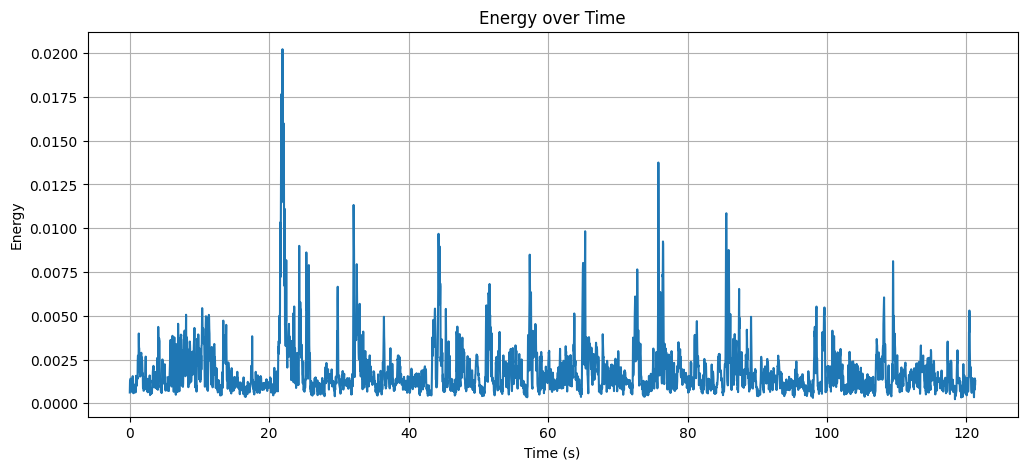

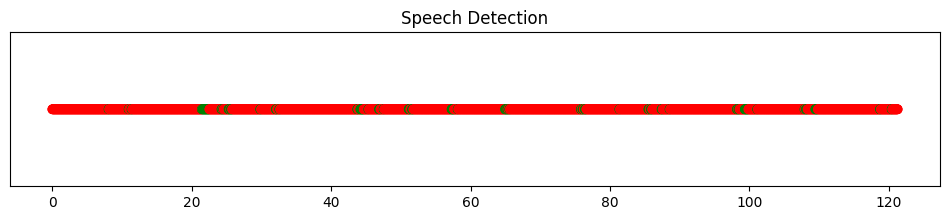


Analysis complete.
Total detected speech duration: 7.86 seconds


In [78]:
# Import and test the office_normal.wav file
audio_file = 'ch08.wav'

if os.path.exists(audio_file):
    # Process the file using our tuned detection function
    results = detect_speech_in_file(audio_file)

    # Calculate total speech duration
    # Each frame in results is 30ms (0.03s)
    speech_frames = sum(1 for r in results if r['is_speech'])
    total_speech_duration = speech_frames * 0.03
    print(f"\nAnalysis complete.")
    print(f"Total detected speech duration: {total_speech_duration:.2f} seconds")
else:
    print(f"Error: {audio_file} not found in the current directory.")